# Finding the companies which are failing

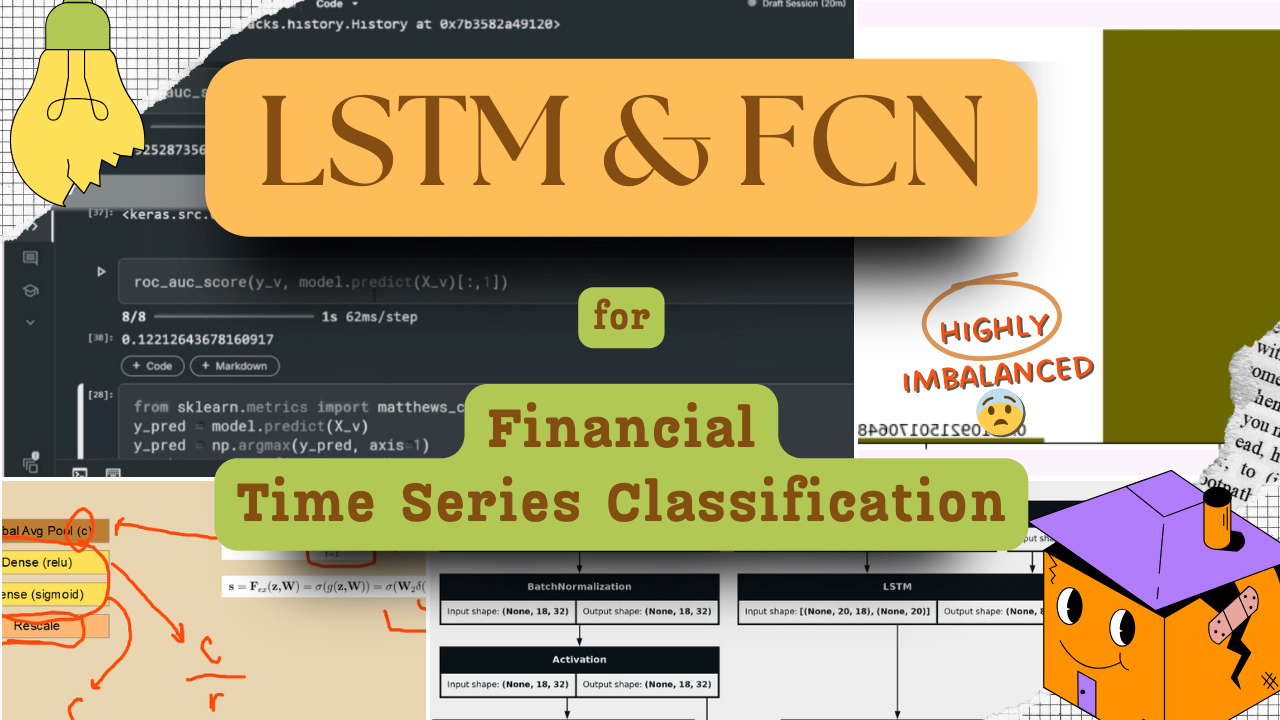

This notebook applies a time series classification model called MLSTMFCN (Multivariate Long Short Term Memory and Fully Convolutional Network) to predict the probability a US company go bankrupt. In this notebook I only include the unweighted model. If you want to see how the weighted model performs, check out this [video](https://youtu.be/OCQZJGItxaU)

# Load libraries and data

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
import tensorflow as tf

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/american-companies-bankruptcy-prediction-dataset/american_bankruptcy.csv


In [2]:
df = pd.read_csv('/kaggle/input/american-companies-bankruptcy-prediction-dataset/american_bankruptcy.csv')
df.head()

,company_name,status_label,year,X1,X2,X3,X4,X5,X6,X7,...,X9,X10,X11,X12,X13,X14,X15,X16,X17,X18
0,C_1,alive,1999,511.267,833.107,18.373,89.031,336.018,35.163,128.348,...,1024.333,740.998,180.447,70.658,191.226,163.816,201.026,1024.333,401.483,935.302
1,C_1,alive,2000,485.856,713.811,18.577,64.367,320.590,18.531,115.187,...,874.255,701.854,179.987,45.790,160.444,125.392,204.065,874.255,361.642,809.888
2,C_1,alive,2001,436.656,526.477,22.496,27.207,286.588,-58.939,77.528,...,638.721,710.199,217.699,4.711,112.244,150.464,139.603,638.721,399.964,611.514
3,C_1,alive,2002,396.412,496.747,27.172,30.745,259.954,-12.410,66.322,...,606.337,686.621,164.658,3.573,109.590,203.575,124.106,606.337,391.633,575.592
4,C_1,alive,2003,432.204,523.302,26.680,47.491,247.245,3.504,104.661,...,651.958,709.292,248.666,20.811,128.656,131.261,131.884,651.958,407.608,604.467


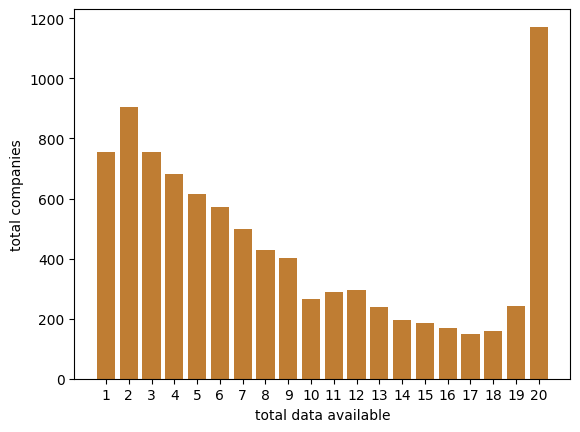

In [3]:
total_years_each_comp = df.groupby('company_name').size()
total_companies = total_years_each_comp.value_counts().sort_index()
plt.bar(total_companies.index, total_companies,color='#BF7D33')
plt.xticks(np.arange(1,21))
plt.xlabel('total data available')
plt.ylabel('total companies');

In [4]:
total_companies/sum(total_companies)

1     0.084160
2     0.100992
3     0.084272
4     0.075911
5     0.068666
6     0.063872
7     0.055401
8     0.047598
9     0.044811
10    0.029540
11    0.032326
12    0.032884
13    0.026753
14    0.021625
15    0.020733
16    0.018727
17    0.016498
18    0.017612
19    0.026976
20    0.130643
Name: count, dtype: float64

# We take companies which have 20 years of data

In [5]:
wanted_comp = total_years_each_comp[total_years_each_comp==20].index

In [6]:
df = df.loc[df.company_name.isin(wanted_comp)]
df

,company_name,status_label,year,X1,X2,X3,X4,X5,X6,X7,...,X9,X10,X11,X12,X13,X14,X15,X16,X17,X18
62,C_7,alive,1999,27.276,15.475,0.729,1.171,5.125,-0.366,17.204,...,23.862,51.073,28.290,0.442,8.387,12.934,-2.683,23.862,41.937,22.691
63,C_7,alive,2000,28.391,71.924,1.951,3.960,7.472,-0.690,17.373,...,89.817,55.896,26.101,2.009,17.893,16.759,-3.984,89.817,48.828,85.857
64,C_7,alive,2001,26.587,71.406,2.076,6.381,7.729,-0.264,17.000,...,90.994,53.030,18.588,4.305,19.588,18.524,-4.901,90.994,43.209,84.613
65,C_7,alive,2002,21.724,63.520,1.254,3.455,7.342,-0.123,12.037,...,78.877,46.677,16.202,2.201,15.357,15.447,-5.202,78.877,37.266,75.422
66,C_7,alive,2003,18.432,55.201,1.192,2.556,4.915,-0.667,11.398,...,68.159,41.154,13.388,1.364,12.958,14.723,-6.603,68.159,33.124,65.603
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
61988,C_6652,alive,2014,941.700,1388.400,94.300,393.200,311.800,217.700,414.300,...,2394.000,2862.200,618.900,298.900,1005.600,539.000,1202.500,2394.000,1393.700,2000.800
61989,C_6652,alive,2015,828.200,1336.400,88.900,377.800,309.200,195.800,401.800,...,2298.100,2718.500,762.900,288.900,961.700,393.600,1308.300,2298.100,1374.400,1920.300
61990,C_6652,alive,2016,846.200,1225.300,85.900,358.900,314.200,190.900,389.100,...,2149.900,2774.400,515.800,273.000,924.600,501.800,1461.200,2149.900,1220.000,1791.000
61991,C_6652,alive,2017,1011.900,1496.400,107.300,465.800,400.200,227.200,478.100,...,2603.800,3846.400,1069.300,358.500,1107.400,540.600,1810.300,2603.800,1899.100,2138.000


# Imbalanced data

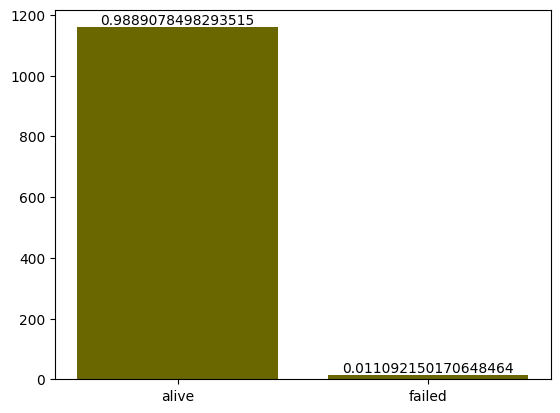

In [7]:
y = df.groupby('company_name')['status_label'].first() #y here is still in strings
class_dist = y.value_counts()
barplot = plt.bar(class_dist.index, class_dist, color='#6A6700')
plt.bar_label(barplot, labels=class_dist/np.sum(class_dist));

In [8]:
class_dist

status_label
alive     1159
failed      13
Name: count, dtype: int64

# Split the data

In [9]:
comp_t, comp_v = train_test_split(wanted_comp, test_size=0.2, random_state=54, stratify=y)

In [10]:
df_t = df.loc[df.company_name.isin(comp_t)]
df_t = df_t.drop('status_label', axis=1)
y_t = y[y.index.isin(comp_t)]

df_v = df.loc[df.company_name.isin(comp_v)]
df_v = df_v.drop('status_label', axis=1)
y_v = y[y.index.isin(comp_v)]

In [11]:
# # TRY NORMALIZE THE DATA FIRST
# from sklearn.preprocessing import MinMaxScaler
# scaler = MinMaxScaler()
# scaler.fit(df_t.iloc[:, 2:])

# df_t = scaler.transform(df_t.iloc[:, 2:])
# df_v = scaler.transform(df_v.iloc[:, 2:])

# # then convert to a numpy matrix
# X_t = np.zeros((len(comp_t), 20, 18))
# for i in range(X_t.shape[0]):
#     X_t[i] = df_t[(20*i):(20*(i+1))]

# X_v = np.zeros((len(comp_v), 20, 18))
# for i in range(X_v.shape[0]):
#     X_v[i] = df_v[(20*i):(20*(i+1))]

# # encode the labels
# y_t = y_t.replace({'alive':0, 'failed':1})
# y_v = y_v.replace({'alive':0, 'failed':1})

In [12]:
# convert to a numpy matrix
X_t = np.zeros((len(comp_t), 20, 18))
for i in range(X_t.shape[0]):
    X_t[i] = df_t.iloc[(20*i):(20*(i+1)), 2:]

X_v = np.zeros((len(comp_v), 20, 18))
for i in range(X_v.shape[0]):
    X_v[i] = df_v.iloc[(20*i):(20*(i+1)), 2:]

# encode the labels
y_t = y_t.replace({'alive':0, 'failed':1})
y_v = y_v.replace({'alive':0, 'failed':1})

/tmp/ipykernel_17/2960278909.py:11: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  y_t = y_t.replace({'alive':0, 'failed':1})
/tmp/ipykernel_17/2960278909.py:12: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  y_v = y_v.replace({'alive':0, 'failed':1})


In [13]:
label_freq = y_v.value_counts()
label_freq

status_label
0    232
1      3
Name: count, dtype: int64

In [14]:
class_weights = {0:len(y_t)/(len(label_freq) * label_freq[0]),
                 1:len(y_t)/(len(label_freq) * label_freq[1])}

# Visualizations

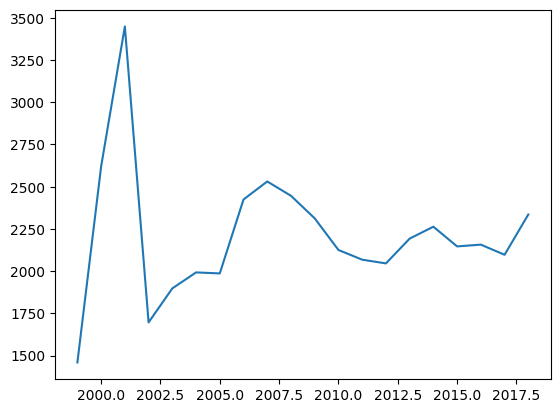

In [15]:
plt.plot(df_t.year.iloc[40:60], df_t.X2.iloc[40:60]);

# Modeling

In [16]:
# BASE ROC SCORE
roc_auc_score(y_v, np.ones(len(y_v)))

0.5

The implementation code is copied from [here](https://github.com/titu1994/MLSTM-FCN/blob/master/net_flow_model.py)

In [17]:
# from github https://github.com/titu1994/MLSTM-FCN/blob/master/net_flow_model.py
# I modified the code a bit, especially the total filters/kernels
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, LSTM, multiply, concatenate, Activation, Masking, Reshape
from tensorflow.keras.layers import Conv1D, BatchNormalization, GlobalAveragePooling1D, Permute, Dropout

def generate_model():
    ip = Input(shape=(20, 18))

    x = Masking()(ip)
    x = LSTM(8)(x)
    x = Dropout(0.8)(x)

    y = Permute((2, 1))(ip)
    y = Conv1D(32, 8, padding='same', kernel_initializer='he_uniform')(y)
    y = BatchNormalization()(y)
    y = Activation('relu')(y)
    y = squeeze_excite_block(y)

    y = Conv1D(64, 5, padding='same', kernel_initializer='he_uniform')(y)
    y = BatchNormalization()(y)
    y = Activation('relu')(y)
    y = squeeze_excite_block(y)

    y = Conv1D(16, 3, padding='same', kernel_initializer='he_uniform')(y)
    y = BatchNormalization()(y)
    y = Activation('relu')(y)

    y = GlobalAveragePooling1D()(y)

    x = concatenate([x, y])

    out = Dense(2, activation='softmax')(x)

    model = Model(ip, out)
    model.summary()

    # add load model code here to fine-tune

    return model

def squeeze_excite_block(input):
    ''' Create a squeeze-excite block
    Args:
        input: input tensor
        filters: number of output filters
        k: width factor

    Returns: a keras tensor
    '''
    filters = input.shape[-1] # channel_axis = -1 for TF

    se = GlobalAveragePooling1D()(input)
    se = Reshape((1, filters))(se)
    se = Dense(filters // 16,  activation='relu', kernel_initializer='he_normal', use_bias=False)(se)
    se = Dense(filters, activation='sigmoid', kernel_initializer='he_normal', use_bias=False)(se)
    se = multiply([input, se])
    return se

In [18]:
model = generate_model()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 20, 18)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ permute (Permute)   │ (None, 18, 20)    │          0 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 18, 32)    │      5,152 │ permute[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 18, 32)    │        128 │ conv1d[0][0]      │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 18, 32)    │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 32)        │          0 │ activation[0][0]  │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape (Reshape)   │ (None, 1, 32)     │          0 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 1, 2)      │         64 │ reshape[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 1, 32)     │         64 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply (Multiply) │ (None, 18, 32)    │          0 │ activation[0][0], │
│                     │                   │            │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 18, 64)    │     10,304 │ multiply[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 18, 64)    │        256 │ conv1d_1[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 18, 64)    │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 64)        │          0 │ activation_1[0][… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_1 (Reshape) │ (None, 1, 64)     │          0 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 1, 4)      │        256 │ reshape_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 1, 64)     │        256 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply_1          │ (None, 18, 64)    │          0 │ activation_1[0][… │
│ (Multiply)          │                   │            │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal           │ (None, 20, 18)    │          0 │ input_layer[0][0] │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 18, 16)    │      3,088 │ multiply_1[0][0]

 Total params: 20,546 (80.26 KB)

 Trainable params: 20,322 (79.38 KB)

 Non-trainable params: 224 (896.00 B)

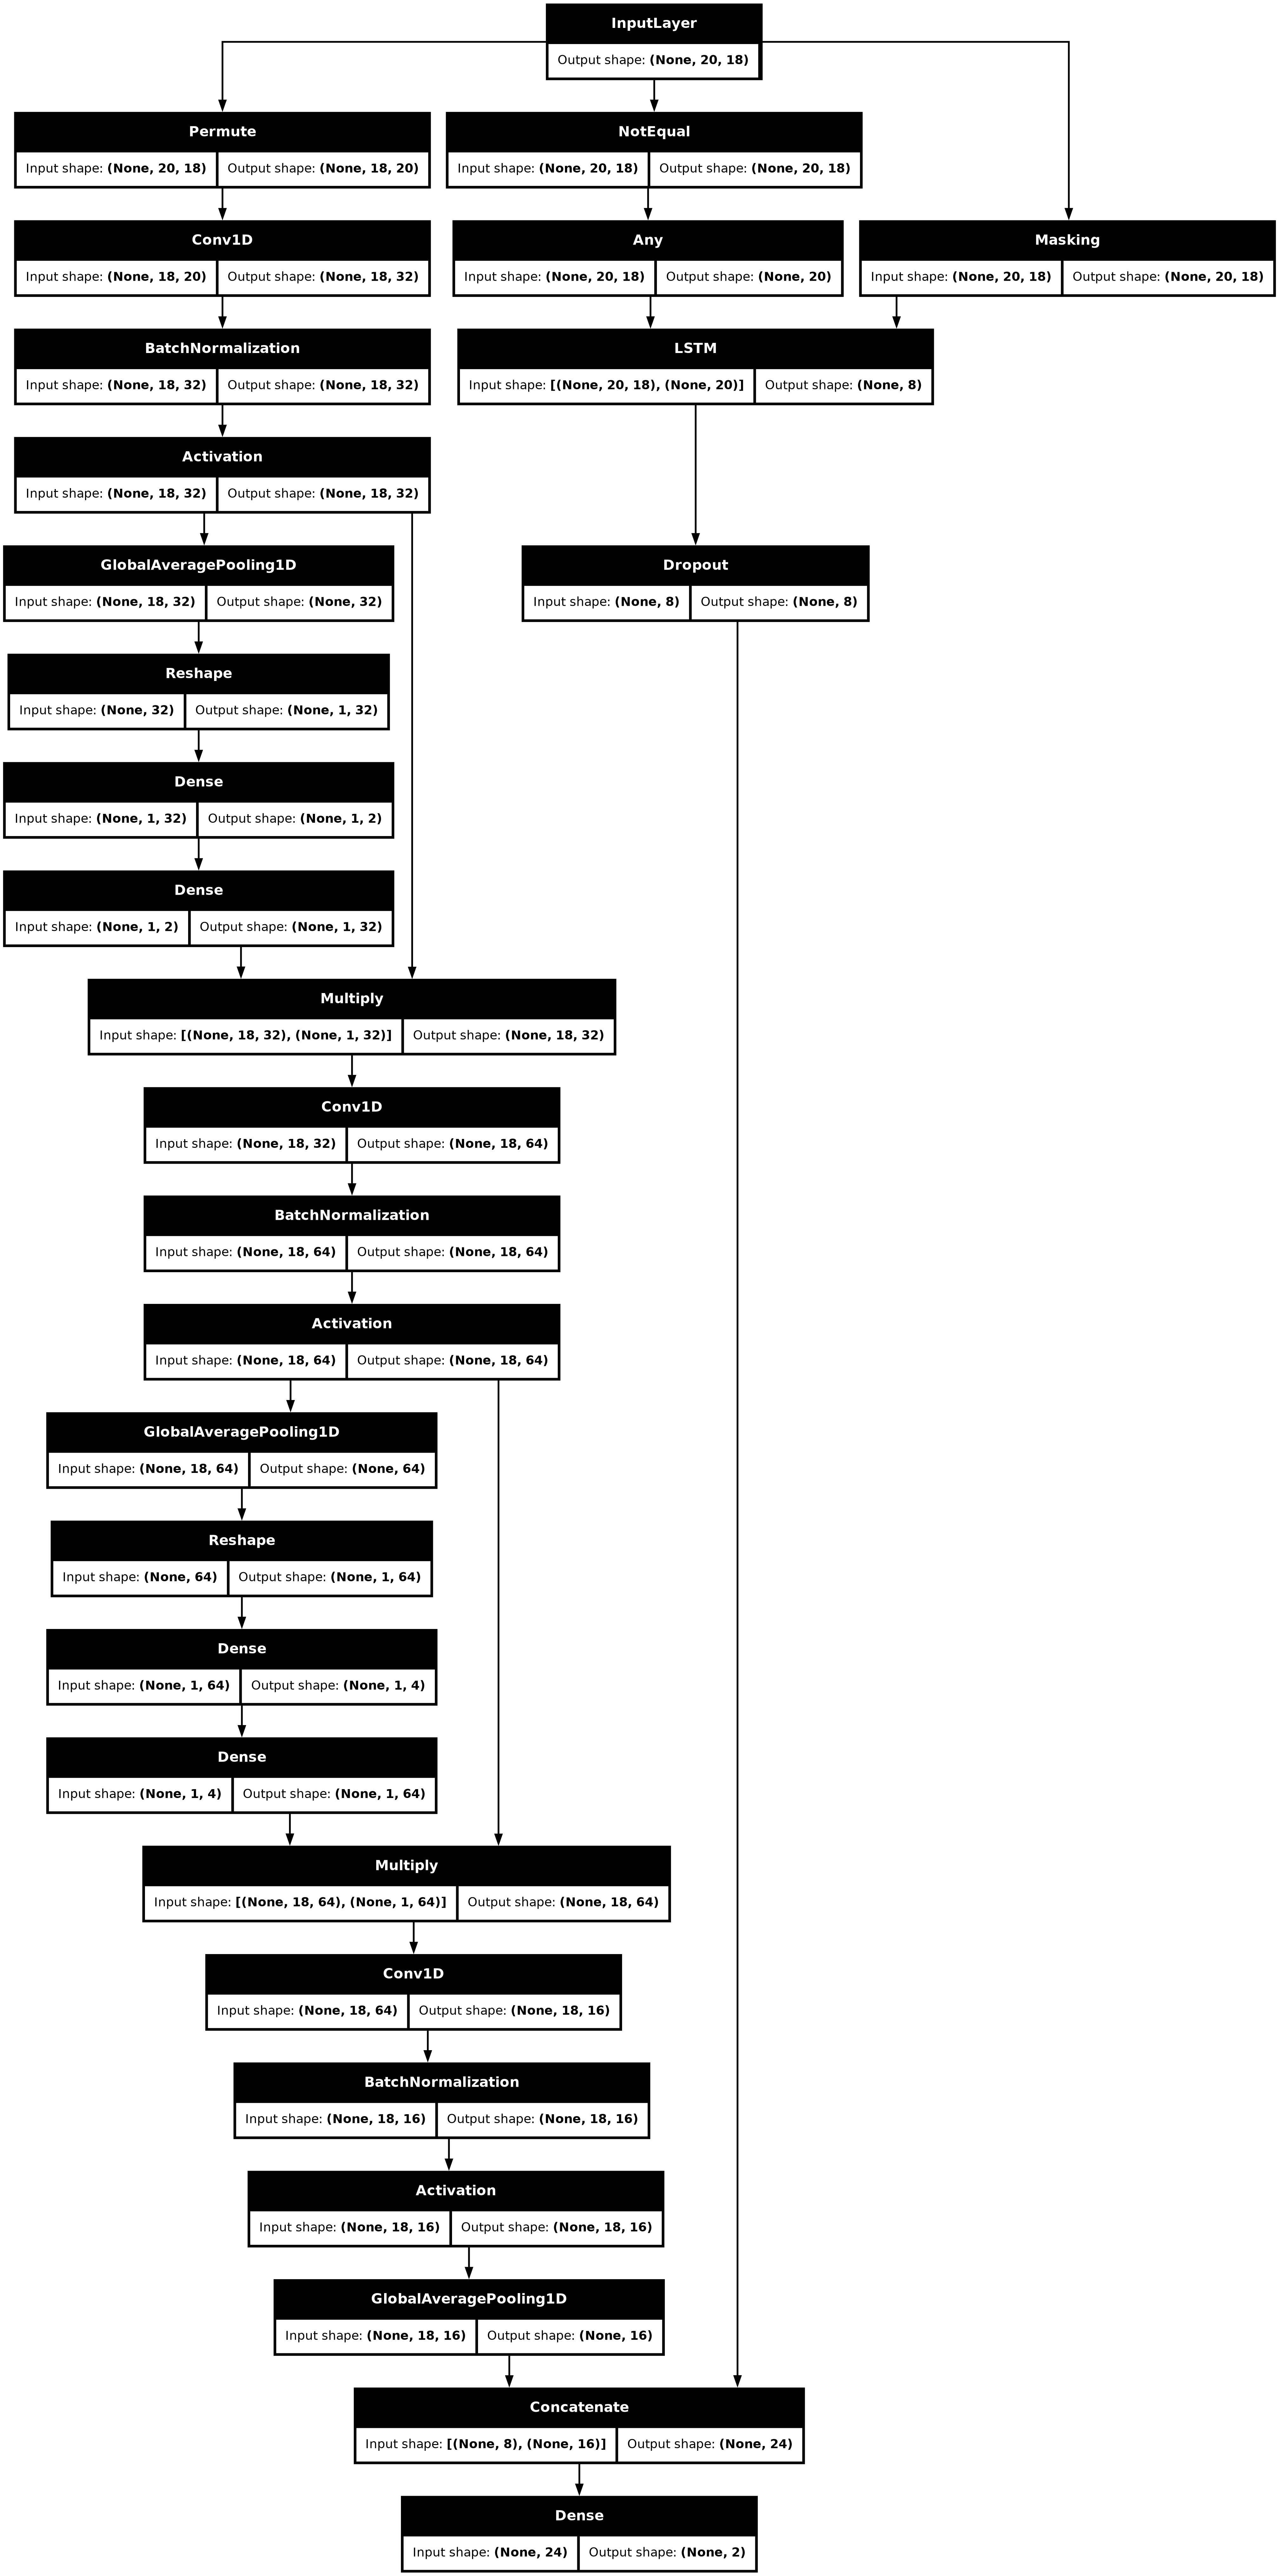

In [19]:
tf.keras.utils.plot_model(model, show_shapes=True)

# Train the model
**Here, I don't use the class weights.**

In [20]:
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4), loss='binary_crossentropy',
              metrics=[tf.keras.metrics.AUC(name='auc'), 'accuracy', 'f1_score'])
model.fit(X_t, pd.get_dummies(y_t), epochs=10, verbose=2, batch_size=32)

Epoch 1/10
30/30 - 7s - 227ms/step - accuracy: 0.5261 - auc: 0.3576 - f1_score: 0.3604 - loss: 0.9890
Epoch 2/10
30/30 - 0s - 15ms/step - accuracy: 0.5592 - auc: 0.3883 - f1_score: 0.3674 - loss: 0.9242
Epoch 3/10
30/30 - 0s - 15ms/step - accuracy: 0.6243 - auc: 0.5015 - f1_score: 0.3949 - loss: 0.8428
Epoch 4/10
30/30 - 0s - 15ms/step - accuracy: 0.6254 - auc: 0.5075 - f1_score: 0.3927 - loss: 0.8329
Epoch 5/10
30/30 - 0s - 15ms/step - accuracy: 0.6350 - auc: 0.5638 - f1_score: 0.3966 - loss: 0.8017
Epoch 6/10
30/30 - 0s - 15ms/step - accuracy: 0.6873 - auc: 0.6213 - f1_score: 0.4263 - loss: 0.7671
Epoch 7/10
30/30 - 0s - 15ms/step - accuracy: 0.6734 - auc: 0.6424 - f1_score: 0.4176 - loss: 0.7542
Epoch 8/10
30/30 - 0s - 15ms/step - accuracy: 0.7022 - auc: 0.7102 - f1_score: 0.4227 - loss: 0.7023
Epoch 9/10
30/30 - 0s - 15ms/step - accuracy: 0.7481 - auc: 0.7707 - f1_score: 0.4401 - loss: 0.6606
Epoch 10/10
30/30 - 0s - 14ms/step - accuracy: 0.7492 - auc: 0.7848 - f1_score: 0.4365 - l

# The metric values

## ROC AUC

In [21]:
roc_auc_score(y_v, model.predict(X_v)[:,1])

8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 62ms/step


0.4511494252873563

## Matthew Correlation Coefficient (MCC)

In [22]:
from sklearn.metrics import matthews_corrcoef
y_pred = model.predict(X_v)
y_pred = np.argmax(y_pred, axis=1)
matthews_corrcoef(y_v, y_pred)

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 


0.016750150506636283

## Using Precision-Recall is better for severely imbalanced data

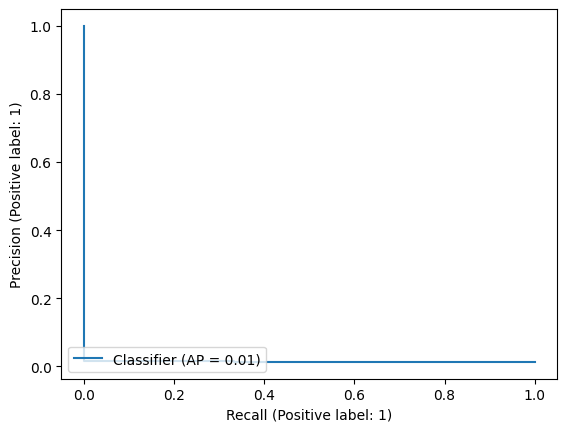

In [23]:
from sklearn.metrics import PrecisionRecallDisplay

disp = PrecisionRecallDisplay.from_predictions(y_v, y_pred)

In [24]:
y_pred

array([0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0,
       1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 1, 0,
       0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1,
       0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0,
       0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1,
       0, 0, 1, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0,
       1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0,
       1, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       1, 0, 0, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0,
       0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0])

## F1 score

In [25]:
from sklearn.metrics import f1_score
f1_score(y_v, y_pred)

0.030303030303030304

## Looking at the predicted probability could help us analyzing the errors our model makes

In [26]:
model.predict(X_v)[:,1]

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 


array([0.36240152, 0.3134192 , 0.35458153, 0.4698231 , 0.5855777 ,
       0.30053467, 0.55827147, 0.43834543, 0.23764554, 0.29197913,
       0.27694654, 0.5080392 , 0.3812028 , 0.69142246, 0.26886123,
       0.5085757 , 0.3598649 , 0.5817198 , 0.4026907 , 0.5320142 ,
       0.33464321, 0.45984218, 0.50782645, 0.49783358, 0.34243566,
       0.3709209 , 0.6248437 , 0.2556854 , 0.36903992, 0.3195008 ,
       0.4603938 , 0.39411175, 0.44520903, 0.43047693, 0.5781158 ,
       0.20360847, 0.33335012, 0.5924066 , 0.5254036 , 0.4435198 ,
       0.52923745, 0.23431417, 0.51406205, 0.3028889 , 0.45246172,
       0.30096933, 0.3228525 , 0.50348115, 0.3536892 , 0.47043973,
       0.41699862, 0.33129683, 0.70074624, 0.5451713 , 0.38414094,
       0.51580256, 0.474701  , 0.42449152, 0.2546725 , 0.43773356,
       0.66953313, 0.5323858 , 0.42259234, 0.31254283, 0.6107862 ,
       0.5303704 , 0.20619965, 0.2484895 , 0.35570717, 0.37028846,
       0.3572864 , 0.66669244, 0.22811782, 0.5098988 , 0.49893

## Accuracy score

In [27]:
from sklearn.metrics import accuracy_score
accuracy_score(y_v, y_pred)

0.7276595744680852

# Which are the "failed" companies?

In [28]:
np.argwhere(y_v)

array([[ 25],
       [ 63],
       [159]])

## Did we get them?

In [29]:
y_pred[[25,63,159]]

array([0, 0, 1])